In [1]:
!pwd

/content


In [23]:
# Library Imports:
# Import libraries
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW #Improved version of the Adam optimizer
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm #Progress bar

# Check GPU
device = "cpu"

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: cuda


In [24]:
# Load the dataset (use the first 100 rows)
from sympy import limit


df = pd.read_csv("./title_conference.csv")

# Encode sentiment labels to numerical values
label_encoder = LabelEncoder()
df['Conference'] = label_encoder.fit_transform(df['Conference'])

In [25]:
# Define custom dataset
class ConferenceDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts # this takes in a list of conference titles [t1,t2,t3]
        self.labels = labels # corresponding labels of the confernece titles [0,1,3,0 ...]
        self.tokenizer = tokenizer # tokenizer from bert-base
        self.max_len = max_len # max_len? max length of input token we process

    def __len__(self):
        return len(self.texts) # returns number of samples

    def __getitem__(self, idx): # get a training example by index
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [26]:
# Tokenize and split dataset
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
dataset = ConferenceDataset(df['Title'].tolist(), df['Conference'].tolist(), tokenizer)

# Split: 80% train, 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [6]:
len(dataset)


2507

In [28]:
model_new = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [29]:
from peft import LoraConfig, get_peft_model
from peft import TaskType

In [30]:
# model is defined
# tokenizer is defined
model_name = "bert-base-uncased"

# 2. Configure LoRA
lora_config_new = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,                     # Rank of the low-rank matrices
    lora_alpha=16,           # Scaling factor
    target_modules=["query", "value"], # Target attention layers
    lora_dropout=0.1,        # Dropout probability
    bias="none"
)

In [31]:
peft_model = get_peft_model(model_new, lora_config_new)
peft_model.print_trainable_parameters()


trainable params: 298,757 || all params: 109,784,842 || trainable%: 0.2721


In [12]:
pip install --upgrade torchao>=0.16.0

In [32]:
peft_model.to(device)

# optimizer = AdamW(peft_model.parameters(), lr=2e-5)

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): BertForSequenceClassification(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): L

In [33]:
optimizer = AdamW(peft_model.parameters(), lr=3e-4)

In [34]:
# using a decaying learning rate
from transformers import get_linear_schedule_with_warmup

epochs = 10

total_steps = len(train_loader) * epochs  # epochs = 10
warmup_steps = int(0.06 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

In [35]:
print(total_steps, warmup_steps)

1260 75


In [36]:
# Training loop
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    peft_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader):
        # move input to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = peft_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward() #Compute gradient
        optimizer.step()
        scheduler.step() #Update weights

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(correct / total)
    print(f"Epoch {epoch+1}: Loss = {train_losses[-1]:.4f}, Accuracy = {train_accuracies[-1]:.4f}")

100%|██████████| 126/126 [00:59<00:00,  2.13it/s]


Epoch 1: Loss = 1.3306, Accuracy = 0.4269


100%|██████████| 126/126 [01:00<00:00,  2.10it/s]


Epoch 2: Loss = 0.9474, Accuracy = 0.6120


100%|██████████| 126/126 [01:01<00:00,  2.05it/s]


...

Epoch 8: Loss = 0.3457, Accuracy = 0.8818


100%|██████████| 126/126 [01:03<00:00,  1.99it/s]


Epoch 9: Loss = 0.3374, Accuracy = 0.8888


100%|██████████| 126/126 [01:03<00:00,  1.99it/s]

Epoch 10: Loss = 0.3052, Accuracy = 0.8943


In [20]:
# Training loop
epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    peft_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader):
        # move input to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = peft_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward() #Compute gradient
        optimizer.step()
        scheduler.step() #Update weights

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(correct / total)
    print(f"Epoch {epoch+1}: Loss = {train_losses[-1]:.4f}, Accuracy = {train_accuracies[-1]:.4f}")

100%|██████████| 126/126 [00:59<00:00,  2.13it/s]


Epoch 1: Loss = 1.1207, Accuracy = 0.5227


100%|██████████| 126/126 [01:01<00:00,  2.05it/s]


Epoch 2: Loss = 0.7674, Accuracy = 0.6853


100%|██████████| 126/126 [01:02<00:00,  2.00it/s]


Epoch 3: Loss = 0.6443, Accuracy = 0.7476


100%|██████████| 126/126 [01:03<00:00,  1.99it/s]


Epoch 4: Loss = 0.6007, Accuracy = 0.7716


100%|██████████| 126/126 [01:03<00:00,  1.99it/s]

Epoch 5: Loss = 0.5604, Accuracy = 0.7880


In [38]:
# nach dem training:

peft_model.save_pretrained("peft_bert_uncased_base_conference_model")

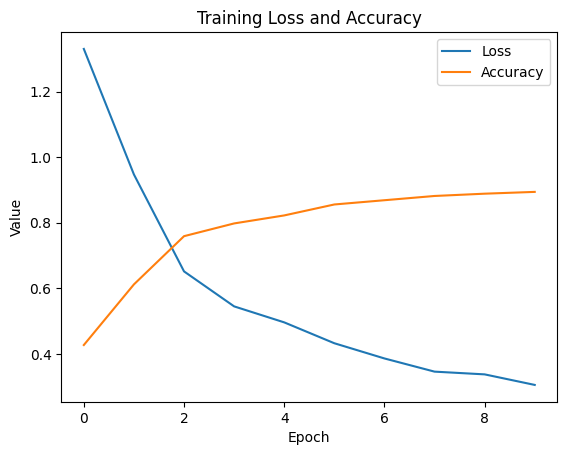

In [37]:
# Plot loss and accuracy curves
plt.plot(train_losses, label='Loss')
plt.plot(train_accuracies, label='Accuracy')
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

#Test/Inference performance


In [39]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import PeftModel

# Load the model for inference
model_loaded = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=5)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# 3. Load PEFT adapter on top of base model
loaded_peft_model = PeftModel.from_pretrained(
    model_loaded,
    "peft_bert_uncased_base_conference_model"  # your saved adapter folder
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [40]:
loaded_peft_model.eval()
loaded_peft_model.to(device)

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): BertForSequenceClassification(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): L

In [41]:
# define the test run loop:
with torch.no_grad():
    correct, total = 0, 0
    test_accuracy = 0
    for batch in tqdm(test_loader):
        # move input to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = loaded_peft_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    test_accuracy = correct/total
    print("Number of test samples: ", total)
    print(f"Accuracy = {test_accuracy:.4f}")



100%|██████████| 32/32 [00:06<00:00,  4.68it/s]

Number of test samples:  502
Accuracy = 0.7928


#Full-tuning the model on dataset

In [42]:
# Library Imports:
# Import libraries
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW #Improved version of the Adam optimizer
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm #Progress bar

# Check GPU
device = "cpu"

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: cuda


In [43]:
# Load the dataset (use the first 100 rows)
from sympy import limit


df = pd.read_csv("title_conference.csv")

# Encode sentiment labels to numerical values
label_encoder = LabelEncoder()
df['Conference'] = label_encoder.fit_transform(df['Conference'])

In [44]:
# Define custom dataset
class ConferenceDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts # this takes in a list of conference titles [t1,t2,t3]
        self.labels = labels # corresponding labels of the confernece titles [0,1,3,0 ...]
        self.tokenizer = tokenizer # tokenizer from bert-base
        self.max_len = max_len # max_len? max length of input token we process

    def __len__(self):
        return len(self.texts) # returns number of samples

    def __getitem__(self, idx): # get a training example by index
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [45]:
# Tokenize and split dataset
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
dataset = ConferenceDataset(df['Title'].tolist(), df['Conference'].tolist(), tokenizer)

# Split: 80% train, 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [46]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=5)
model.to(device)

# Define optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [47]:
# Training loop
epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader):
        # move input to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward() #Compute gradient
        optimizer.step() #Update weights

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(correct / total)
    print(f"Epoch {epoch+1}: Loss = {train_losses[-1]:.4f}, Accuracy = {train_accuracies[-1]:.4f}")

100%|██████████| 126/126 [01:19<00:00,  1.59it/s]


Epoch 1: Loss = 1.0368, Accuracy = 0.6100


100%|██████████| 126/126 [01:22<00:00,  1.52it/s]


Epoch 2: Loss = 0.4877, Accuracy = 0.8374


100%|██████████| 126/126 [01:25<00:00,  1.48it/s]


...

Epoch 8: Loss = 0.0247, Accuracy = 0.9935


100%|██████████| 126/126 [01:26<00:00,  1.45it/s]


Epoch 9: Loss = 0.0256, Accuracy = 0.9930


100%|██████████| 126/126 [01:26<00:00,  1.45it/s]

Epoch 10: Loss = 0.0234, Accuracy = 0.9940


In [48]:
# Save trained model
torch.save(model.state_dict(), "bert_conference_model.pt")

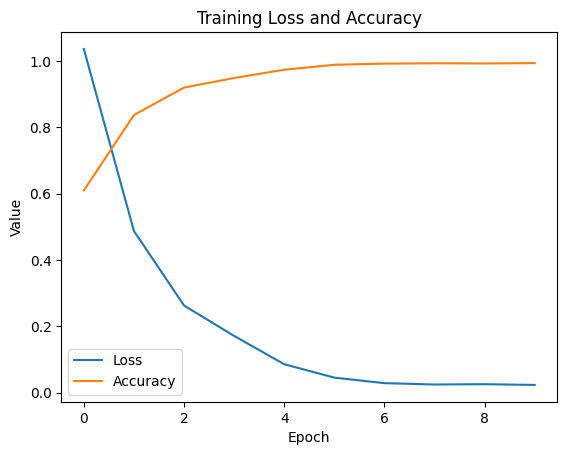

In [49]:
# Plot loss and accuracy curves
plt.plot(train_losses, label='Loss')
plt.plot(train_accuracies, label='Accuracy')
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.show()

In [50]:
# Load the model for inference
model_loaded = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=5)
model_loaded.load_state_dict(torch.load("bert_conference_model.pt"))
model_loaded.to(device)
model_loaded.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [51]:
# define the test run loop:
with torch.no_grad():
    correct, total = 0, 0
    test_accuracy = 0
    for batch in tqdm(test_loader):
        # move input to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_loaded(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    test_accuracy = correct/total
    print("Number of test samples: ", total)
    print(f"Accuracy = {test_accuracy:.4f}")



100%|██████████| 32/32 [00:06<00:00,  4.84it/s]

Number of test samples:  502
Accuracy = 0.8167
